In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('C:/Users/H246o/Downloads/archive (1)/spam.csv', encoding='cp1252')

In [3]:
pd.read_csv('C:/Users/H246o/Downloads/archive (1)/spam.csv', encoding='cp1252')

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


# 1. Data Cleaning

In [4]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [6]:
df.sample(5)

,v1,v2
1361,ham,Shuhui say change 2 suntec steamboat? U noe wh...
2501,ham,No da..today also i forgot..
3389,spam,Please CALL 08712402972 immediately as there i...
2484,ham,Only if you promise your getting out as SOON a...
5522,ham,Thats cool. I want to please you...


In [7]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1779,spam,"Loan for any purpose å£500 - å£75,000. Homeown..."
515,ham,S:)no competition for him.
3607,ham,Pls come quick cant bare this.
1036,ham,"No my blankets are sufficient, thx"
1405,ham,K..k..any special today?


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [9]:
df['target'] = encoder.fit_transform(df['target'])

In [10]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
# check for duplicate values
df.duplicated ().sum()

np.int64(403)

In [13]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

# 2.EDA

In [16]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

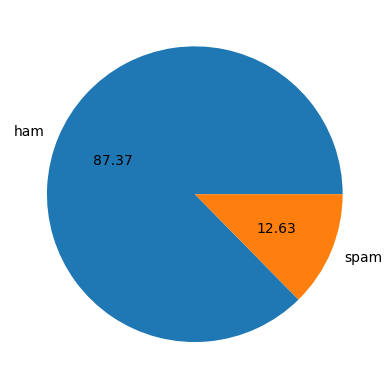

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [19]:
# Data is imbalanced

In [20]:
import nltk

In [21]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\H246o\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:
df['num_charcters'] = df['text'].apply(len)

In [24]:
df.head()

,target,text,num_charcters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\H246o\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
# num of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [27]:
df.head()

,target,text,num_charcters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [28]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [29]:
df.head()

,target,text,num_charcters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [30]:
df[['num_charcters', 'num_words', 'num_sentences']].describe()

,num_charcters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
# 1. Fix the typo column permanently
df.rename(columns={'num_charcters': 'num_characters'}, inplace=True)

# 2. Import seaborn so your plots work
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Ham messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
# Spam messages
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [34]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

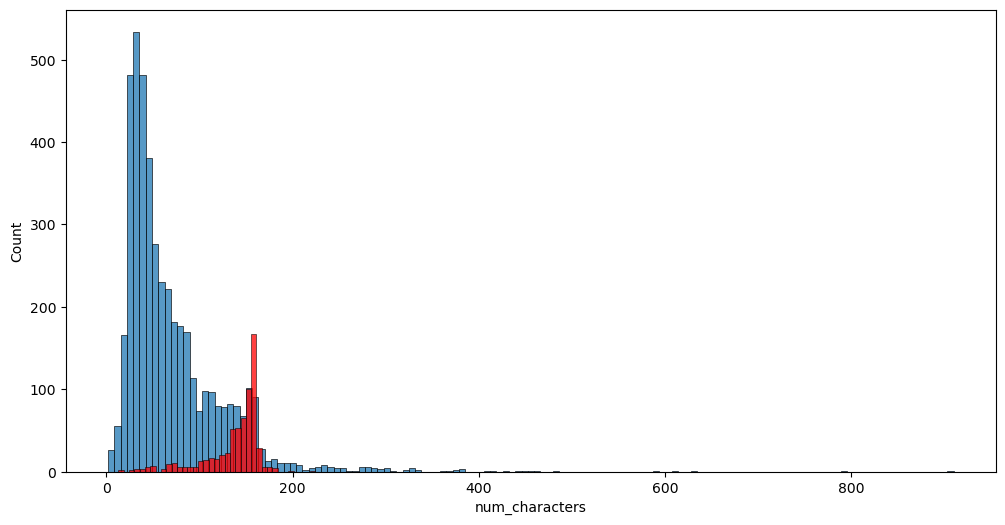

In [35]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

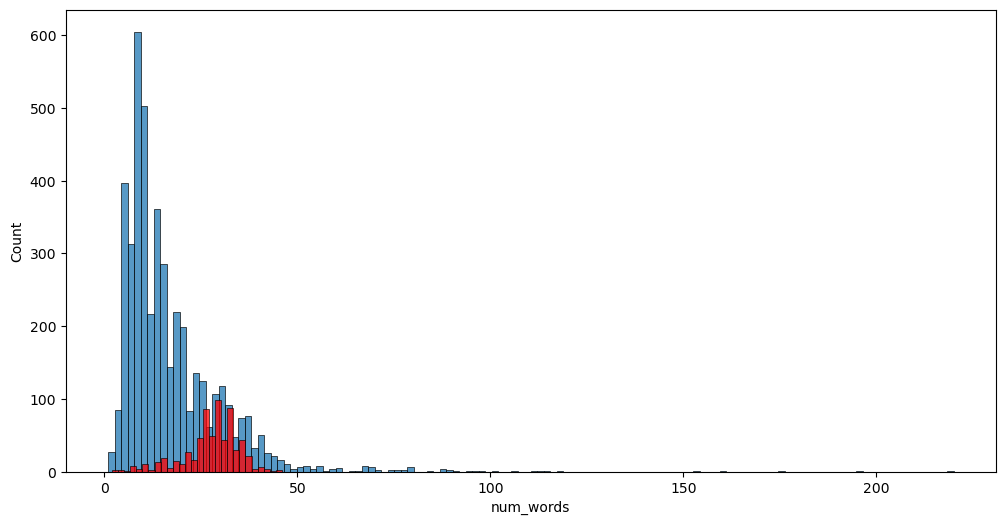

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

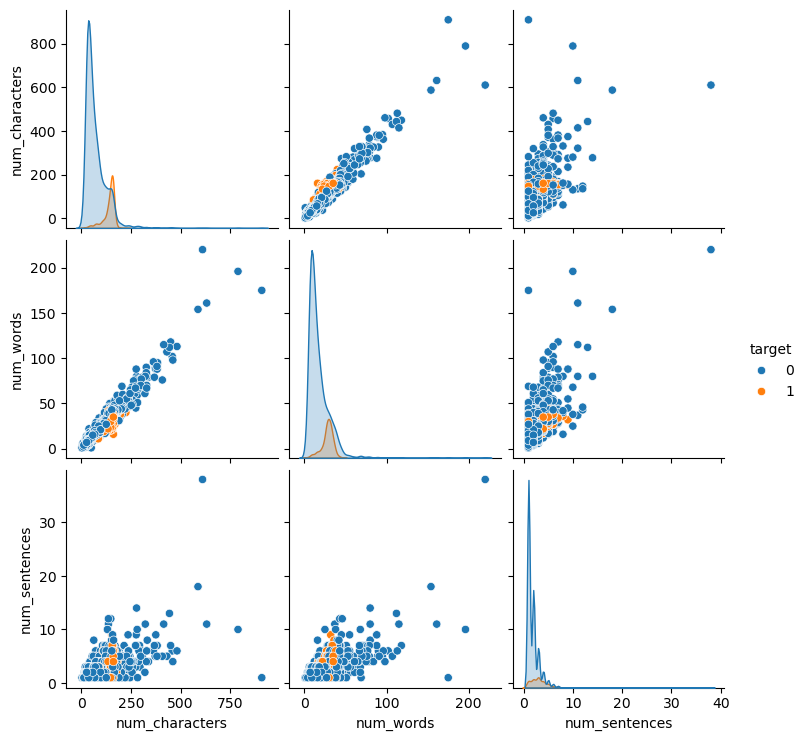

In [37]:
sns.pairplot(df,hue='target')

<Axes: >

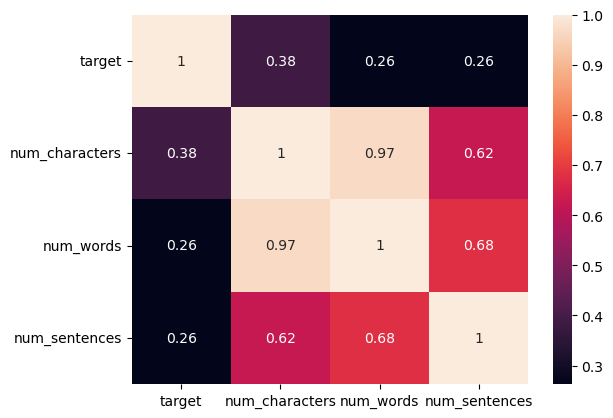

In [38]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# 3.Data Preprocessing
.Lower case

.Tokenization

.Removing special characters

.Removing stop words and punctuation

.Stemming

In [39]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
            text = y[:]
            y. clear()
            
            for i in text:
                if i not in stopwords.words('english') and i not in string.punctuation:
                    y.append(i)
                    text = y[:]
                    y.clear()
                    for i in text:
                        y.append(ps.stem(i))
    return  " ".join(y)

In [40]:
import string
from nltk.corpus import stopwords

# You also need to make sure the stopwords dataset is downloaded
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\H246o\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('punkt') # Ensures tokenizer data is downloaded

ps = PorterStemmer()

def transform_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Tokenize into individual words (Fixes the character-looping bug)
    words = nltk.word_tokenize(text)
    
    # 3. Stem each word
    y = []
    for i in words:
        y.append(ps.stem(i))
        
    return " ".join(y)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\H246o\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [42]:
transform_text('did you like my presentation on ML?')

'did you like my present on ml ?'

In [43]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [44]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [45]:
df['transformed_text'] = df['text'].apply(transform_text)

In [46]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point , crazi .. avail onli in..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar ... joke wif u oni ...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri in 2 a wkli comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so earli hor ... u c alreadi then sa...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i do n't think he goe to usf , he live aro..."


In [47]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [48]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [49]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=""))

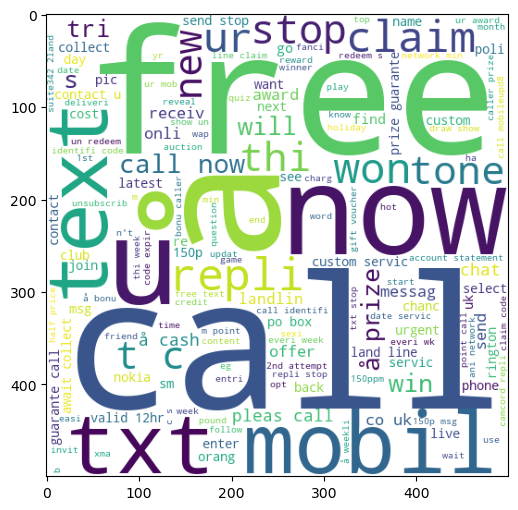

In [50]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [51]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=""))

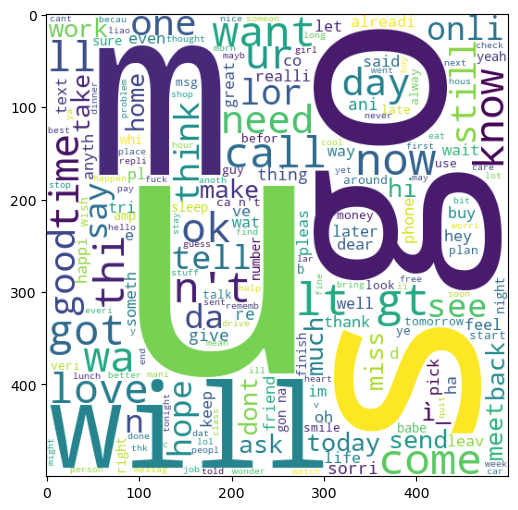

In [52]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [53]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point , crazi .. avail onli in..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar ... joke wif u oni ...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri in 2 a wkli comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so earli hor ... u c alreadi then sa...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i do n't think he goe to usf , he live aro..."


In [54]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [55]:
len(spam_corpus)

17983

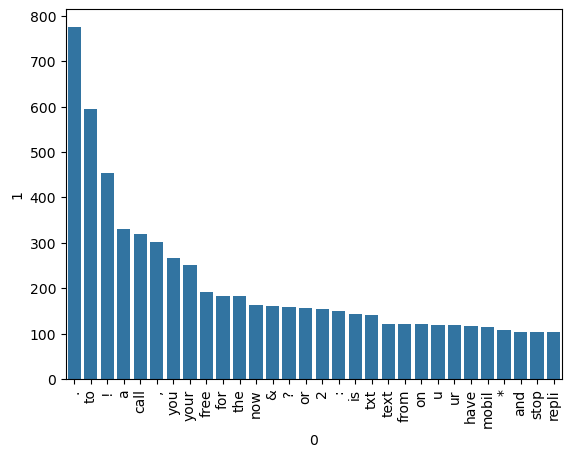

In [56]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=most_common_df[0], y=most_common_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [57]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [58]:
len(ham_corpus)

77261

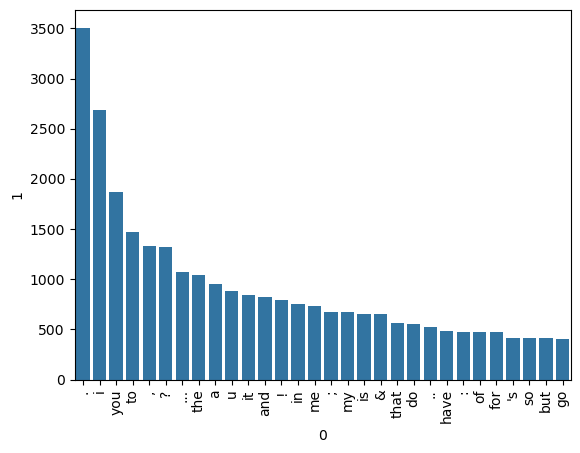

In [59]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
most_common_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=most_common_df[0], y=most_common_df[1])
plt.xticks(rotation='vertical')
plt.show()

# 4.Model Building

In [60]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [61]:
import pandas as pd

# Add the encoding parameter to successfully read the file
df = pd.read_csv('C:/Users/H246o/Downloads/archive/spam.csv', encoding='latin-1')

In [62]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [63]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

# Initialize the stemmer
ps = PorterStemmer()

def transform_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Tokenize into words
    text = nltk.word_tokenize(text)
    
    # 3. Remove special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    # 4. Remove stop words and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    # 5. Apply stemming (PorterStemmer)
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [64]:
# You need to re-run this line (or your equivalent loop/apply function) 
df['transformed_text'] = df['v2'].apply(transform_text)

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
tfidf = TfidfVectorizer()

In [66]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [67]:
x.shape

(5572, 6708)

In [68]:
# 1. Rename the original columns so 'v1' becomes 'target'
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

# 2. Map 'ham' to 0 and 'spam' to 1
df['target'] = df['target'].map({'ham': 0, 'spam': 1})

# 3. Extract your numeric y values now that the column exists!
y = df['target'].values

# 4. Re-split your data (making sure your x and y match up perfectly)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [69]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [72]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [73]:
# Use lowercase x_train and x_test to match your train_test_split output
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

Accuracy: 0.8690582959641255
Confusion Matrix:
 [[844 113]
 [ 33 125]]
Precision: 0.5252100840336135


In [74]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.957847533632287
[[957   0]
 [ 47 111]]
1.0


In [75]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.957847533632287
[[957   0]
 [ 47 111]]
1.0


In [76]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


# tfidf --> MNB

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
# FIXED: Removed the stray 'I' from this line
from sklearn.tree import DecisionTreeClassifier
# FIXED: Removed the space in KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
# FIXED: Removed the space in RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
# FIXED: Removed the space in ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [78]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [79]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,       
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [80]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    # Train the model
    clf.fit(x_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(x_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate precision (handles 'spam'/'ham' text labels automatically if needed)
    try:
        precision = precision_score(y_test, y_pred)
    except ValueError:
        precision = precision_score(y_test, y_pred, pos_label='spam')
        
    return accuracy, precision

In [81]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9659192825112107, 0.9761904761904762)

In [82]:
accuracy_scores = []
precision_scores = []
# 1. The loop starts here
for name, clf in clfs.items():
    # Changed 'svc' to 'clf' here so it tests every model
    current_accuracy, current_precision = train_classifier(clf, x_train, y_train, x_test, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9659192825112107
Precision -  0.9761904761904762
For  KN
Accuracy -  0.8986547085201794
Precision -  1.0
For  NB
Accuracy -  0.957847533632287
Precision -  1.0
For  DT
Accuracy -  0.9264573991031391
Precision -  0.8725490196078431
For  LR
Accuracy -  0.9443946188340807
Precision -  0.9444444444444444
For  RF
Accuracy -  0.9650224215246637
Precision -  0.983739837398374
For  AdaBoost
Accuracy -  0.9130044843049328
Precision -  0.9066666666666666
For  BgC
Accuracy -  0.9587443946188341
Precision -  0.9242424242424242
For  ETC
Accuracy -  0.9695067264573991
Precision -  1.0
For  GBDT
Accuracy -  0.9426008968609866
Precision -  0.9607843137254902
For  xgb
Accuracy -  0.9632286995515695
Precision -  0.975609756097561


In [83]:
import pandas as pd

# Fixed the missing closing parenthesis after list(clfs.keys())
performance_df = pd.DataFrame({
    'Algorithm': list(clfs.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Accuracy', ascending=False)

In [84]:
# Display the dataframe
performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.969507,1.000000
0,SVC,0.965919,0.976190
5,RF,0.965022,0.983740
10,xgb,0.963229,0.975610
7,BgC,0.958744,0.924242
2,NB,0.957848,1.000000
4,LR,0.944395,0.944444
9,GBDT,0.942601,0.960784
3,DT,0.926457,0.872549
6,AdaBoost,0.913004,0.906667


In [85]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [86]:
performance_df1

,Algorithm,variable,value
0,ETC,Accuracy,0.969507
1,SVC,Accuracy,0.965919
2,RF,Accuracy,0.965022
3,xgb,Accuracy,0.963229
4,BgC,Accuracy,0.958744
5,NB,Accuracy,0.957848
6,LR,Accuracy,0.944395
7,GBDT,Accuracy,0.942601
8,DT,Accuracy,0.926457
9,AdaBoost,Accuracy,0.913004


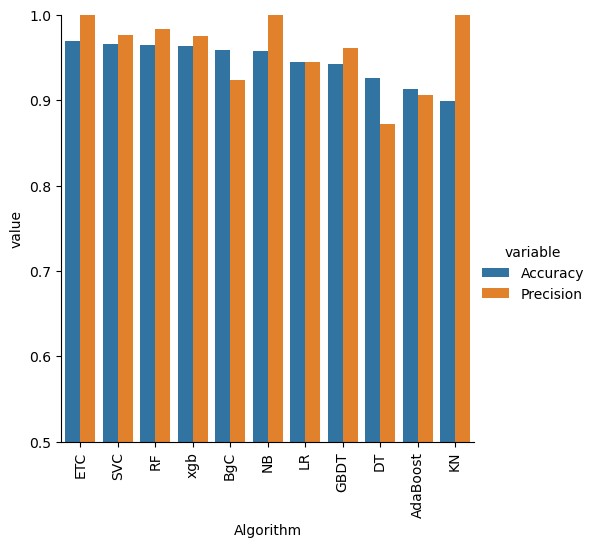

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed 'values' to 'value'
sns.catplot(
    x='Algorithm', 
    y='value', 
    hue='variable', 
    data=performance_df1, 
    kind='bar', 
    height=5
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

In [88]:
import pandas as pd

# Completed DataFrame code
temp_df = pd.DataFrame({
    'Algorithm': list(clfs.keys()),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores,
})

In [89]:
performance_df.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,ETC,0.969507,1.000000,0.969507,1.000000
1,SVC,0.965919,0.976190,0.965919,0.976190
2,RF,0.965022,0.983740,0.965022,0.983740
3,xgb,0.963229,0.975610,0.963229,0.975610
4,BgC,0.958744,0.924242,0.958744,0.924242
5,NB,0.957848,1.000000,0.957848,1.000000
6,LR,0.944395,0.944444,0.944395,0.944444
7,GBDT,0.942601,0.960784,0.942601,0.960784
8,DT,0.926457,0.872549,0.926457,0.872549
9,AdaBoost,0.913004,0.906667,0.913004,0.906667


In [90]:
# voting classifier
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)

# 1. Fixed lowercase 'm' to uppercase 'M'
mnb = MultinomialNB() 

etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

# 2. Fixed lowercase 'v' to uppercase 'V'
from sklearn.ensemble import VotingClassifier

In [91]:
# Fixed lowercase 'v' to uppercase 'V'
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], voting='soft')

# Train the voting classifier
voting.fit(x_train, y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [92]:
y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9713004484304932
Precision 1.0


In [93]:
#Applying stacking
estimators=[('svm',svc),('nb',mnb),('et',etc)]
final_estimator=RandomForestClassifier()

In [94]:
# Fixed lowercase 's' to uppercase 'S'
from sklearn.ensemble import StackingClassifier

In [95]:
# Fixed lowercase 's' to uppercase 'S'
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [98]:
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
# Fixed Capitalization to lowercase precision_score
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.979372197309417
Precision: 0.9787234042553191


In [99]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))